In [1]:
## Setup — packages & environment

# Install and import required packages
import sys
import subprocess

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

required = [
    'pandas', 'numpy', 'scipy', 'matplotlib', 'seaborn', 'scikit-learn',
    'openpyxl', 'reportlab'
]

for pkg in required:
    try:
        __import__(pkg.split('-')[0])
    except Exception:
        install(pkg)

# Common imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime as dt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from scipy import stats

# Reproducibility
RSEED = 2023
np.random.seed(RSEED)

# Plotting
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

In [2]:
# Check for ipykernel
try:
    import ipykernel
    print('ipykernel is installed:', ipykernel.__version__)
except Exception as e:
    print('ipykernel is NOT installed. Recommended: pip install ipykernel')

ipykernel is installed: 6.28.0


In [3]:
## 1. Data Loading and Preprocessing

DATA_DIR = '../../data-main/6_snaMOOC'

# Load centrality measures
centralities_path = os.path.join(DATA_DIR, 'Centralities.csv')
print('Centralities path:', centralities_path)

try:
    centralities = pd.read_csv(centralities_path)
    print('Centralities shape:', centralities.shape)
    print('Columns:', centralities.columns.tolist())
    display(centralities.head())
except FileNotFoundError as e:
    print(f'Error loading centralities: {e}')
    print('Creating a synthetic dataset for demonstration...')
    # Create synthetic data for testing
    np.random.seed(RSEED)
    n_nodes = 40
    centralities = pd.DataFrame({
        'node_id': [f'student_{i}' for i in range(n_nodes)],
        'degree': np.random.uniform(2, 25, n_nodes),
        'betweenness': np.random.uniform(0, 0.6, n_nodes),
        'closeness': np.random.uniform(0.2, 0.95, n_nodes),
        'eigenvector': np.random.uniform(0, 1, n_nodes)
    })
    print('Created synthetic centrality dataset')
    display(centralities.head())

Centralities path: ../../data-main/6_snaMOOC\Centralities.csv
Centralities shape: (445, 9)
Columns: ['name', 'InDegree', 'OutDegree', 'Closeness_total', 'Betweenness', 'Eigen', 'Diffusion.degree', 'Coreness', 'Cross_clique_connectivity']


,name,InDegree,OutDegree,Closeness_total,Betweenness,Eigen,Diffusion.degree,Coreness,Cross_clique_connectivity
0,1,20,33,0.001095,1258.143185,0.205523,1865,18,305
1,2,2,5,0.000808,26.524289,0.010718,218,6,13
2,3,2,4,0.000799,30.601120,0.008624,191,6,11
3,4,2,14,0.001019,72.523454,0.080265,965,13,37
4,5,16,17,0.001060,309.032739,0.161504,1508,18,154


In [4]:
## 2. Exploratory Data Analysis (EDA)

print('Data summary:')
print(centralities.describe())

# Feature selection for clustering
feature_cols = [col for col in centralities.columns if col != 'node_id']
X = centralities[feature_cols].values
print(f'\nFeatures for clustering: {feature_cols}')
print(f'Sample size: {X.shape[0]}')
print(f'Number of features: {X.shape[1]}')

# Standardize features (essential for GMM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('\nFeatures standardized (mean=0, std=1)')
print('Scaled data shape:', X_scaled.shape)

Data summary:
             name    InDegree   OutDegree  Closeness_total   Betweenness  \
count  445.000000  445.000000  445.000000       442.000000    445.000000   
mean   223.000000    5.683146    5.683146         0.000933    371.736847   
std    128.604691   26.735960    9.842490         0.000128   2893.811713   
min      1.000000    0.000000    0.000000         0.000565      0.000000   
25%    112.000000    0.000000    1.000000         0.000834      0.000000   
50%    223.000000    1.000000    2.000000         0.000976     24.176440   
75%    334.000000    5.000000    6.000000         0.001020    198.491061   
max    445.000000  475.000000  106.000000         0.001695  58205.587358   

            Eigen  Diffusion.degree    Coreness  Cross_clique_connectivity  
count  445.000000        445.000000  445.000000                 445.000000  
mean     0.041980        691.402247    6.008989                  52.770787  
std      0.078842        532.568595    6.053062                 205.73

In [6]:
## 3. Fit Gaussian Mixture Models with BIC/AIC selection

# Handle missing values: drop rows with NaN (expect 3 rows with missing Closeness_total)
centralities_clean = centralities.dropna()
print(f'Removed {len(centralities) - len(centralities_clean)} rows with missing values')
print(f'Clean data shape: {centralities_clean.shape}')

# Extract features from clean data
feature_cols = [col for col in centralities_clean.columns if col != 'name']
X_clean = centralities_clean[feature_cols].values

# Standardize the clean data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
print(f'Scaled data shape: {X_scaled.shape}')

# Test different numbers of components
n_components_range = range(1, 11)
bic_scores = []
aic_scores = []
models = {}

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=RSEED, n_init=10)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    models[n_components] = gmm
    print(f'n_components={n_components}: BIC={gmm.bic(X_scaled):.2f}, AIC={gmm.aic(X_scaled):.2f}')

# Identify optimal components
optimal_n_bic = n_components_range[np.argmin(bic_scores)]
optimal_n_aic = n_components_range[np.argmin(aic_scores)]
print(f'\nOptimal n_components (BIC): {optimal_n_bic}')
print(f'Optimal n_components (AIC): {optimal_n_aic}')

# Use optimal model
optimal_gmm = models[optimal_n_bic]
print(f'\nUsing GMM with {optimal_n_bic} components')

Removed 3 rows with missing values
Clean data shape: (442, 9)
Scaled data shape: (442, 8)


C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\clust

n_components=1: BIC=3616.02, AIC=3436.00


C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\clust

n_components=2: BIC=-3422.17, AIC=-3786.30


...

n_components=8: BIC=-7274.61, AIC=-8743.39


C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\clust

n_components=9: BIC=-7600.49, AIC=-9253.38


C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\clust

n_components=10: BIC=-7578.28, AIC=-9415.28

Optimal n_components (BIC): 9
Optimal n_components (AIC): 10

Using GMM with 9 components


In [8]:
## 4. Cluster Assignment and Probability Analysis

# Get hard cluster assignments
cluster_labels = optimal_gmm.predict(X_scaled)

# Get soft cluster probabilities
cluster_probs = optimal_gmm.predict_proba(X_scaled)
max_prob = cluster_probs.max(axis=1)
entropy = -np.sum(cluster_probs * np.log(cluster_probs + 1e-10), axis=1)

# Add to clean dataframe (not original; use centralities_clean with 442 rows)
centralities_clean['GMM_Cluster'] = cluster_labels
centralities_clean['Assignment_Probability'] = max_prob
centralities_clean['Entropy'] = entropy

# Summary statistics
print('Cluster distribution:')
print(centralities_clean['GMM_Cluster'].value_counts().sort_index())
print(f'\nMean assignment probability: {max_prob.mean():.4f} (std: {max_prob.std():.4f})')
print(f'Mean entropy: {entropy.mean():.4f} (std: {entropy.std():.4f})')
print('\nNodes with low confidence (<0.8 probability):')
low_conf = centralities_clean[centralities_clean['Assignment_Probability'] < 0.8]
print(f'Count: {len(low_conf)} out of {len(centralities_clean)}')
display(low_conf.head(10))

Cluster distribution:
GMM_Cluster
0    127
1      1
2     49
3     67
4      5
5      1
6     39
7     61
8     92
Name: count, dtype: int64

Mean assignment probability: 0.9914 (std: 0.0487)
Mean entropy: 0.0220 (std: 0.0930)

Nodes with low confidence (<0.8 probability):
Count: 7 out of 442


C:\Users\MyName\AppData\Local\Temp\ipykernel_14660\3966120283.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  centralities_clean['GMM_Cluster'] = cluster_labels
C:\Users\MyName\AppData\Local\Temp\ipykernel_14660\3966120283.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  centralities_clean['Assignment_Probability'] = max_prob
C:\Users\MyName\AppData\Local\Temp\ipykernel_14660\3966120283.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

,name,InDegree,OutDegree,Closeness_total,Betweenness,Eigen,Diffusion.degree,Coreness,Cross_clique_connectivity,GMM_Cluster,Assignment_Probability,Entropy
9,10,8,12,0.001058,716.350787,0.087487,1432,17,88,6,0.568105,0.683842
45,46,2,9,0.000881,130.254015,0.019176,525,8,16,2,0.642717,0.651839
100,101,9,3,0.001038,286.728789,0.033497,1076,7,31,2,0.535952,0.690560
135,136,12,13,0.001045,458.489625,0.087508,1238,16,64,2,0.753235,0.559219
183,184,3,9,0.001038,132.358666,0.057577,1214,9,45,8,0.571627,0.682852
184,185,1,13,0.001040,208.188937,0.055623,1161,10,45,8,0.598987,0.673424
192,193,11,11,0.001041,176.226513,0.084720,1191,16,50,8,0.775330,0.687718


In [9]:
## 5. Model Parameters and Cluster Characteristics

print('GMM Parameters:')
print(f'Converged: {optimal_gmm.converged_}')
print(f'Number of iterations: {optimal_gmm.n_iter_}')
print(f'Log-likelihood: {optimal_gmm.score(X_scaled):.4f}')

# Cluster means and covariances
print('\nCluster Means (in original scale):')
for i in range(optimal_n_bic):
    means_original = scaler.inverse_transform(optimal_gmm.means_[i:i+1])[0]
    print(f'\nCluster {i}:')
    for feat, val in zip(feature_cols, means_original):
        print(f'  {feat}: {val:.4f}')

GMM Parameters:
Converged: True
Number of iterations: 16
Log-likelihood: 11.3817

Cluster Means (in original scale):

Cluster 0:
  InDegree: 0.4337
  OutDegree: 1.8064
  Closeness_total: 0.0010
  Betweenness: 9.2529
  Eigen: 0.0215
  Diffusion.degree: 658.5409
  Coreness: 2.2400
  Cross_clique_connectivity: 3.9455

Cluster 1:
  InDegree: 276.0000
  OutDegree: 56.0000
  Closeness_total: 0.0013
  Betweenness: 16690.4261
  Eigen: 0.6992
  Diffusion.degree: 3574.0000
  Coreness: 31.0000
  Cross_clique_connectivity: 2218.0000

Cluster 2:
  InDegree: 8.7239
  OutDegree: 9.1518
  Closeness_total: 0.0010
  Betweenness: 537.9194
  Eigen: 0.0573
  Diffusion.degree: 943.4949
  Coreness: 10.8513
  Cross_clique_connectivity: 50.6001

Cluster 3:
  InDegree: 0.3136
  OutDegree: 1.2222
  Closeness_total: 0.0007
  Betweenness: 1.8287
  Eigen: 0.0019
  Diffusion.degree: 36.4044
  Coreness: 1.5358
  Cross_clique_connectivity: 2.5796

Cluster 4:
  InDegree: 38.2000
  OutDegree: 55.4000
  Closeness_total: 

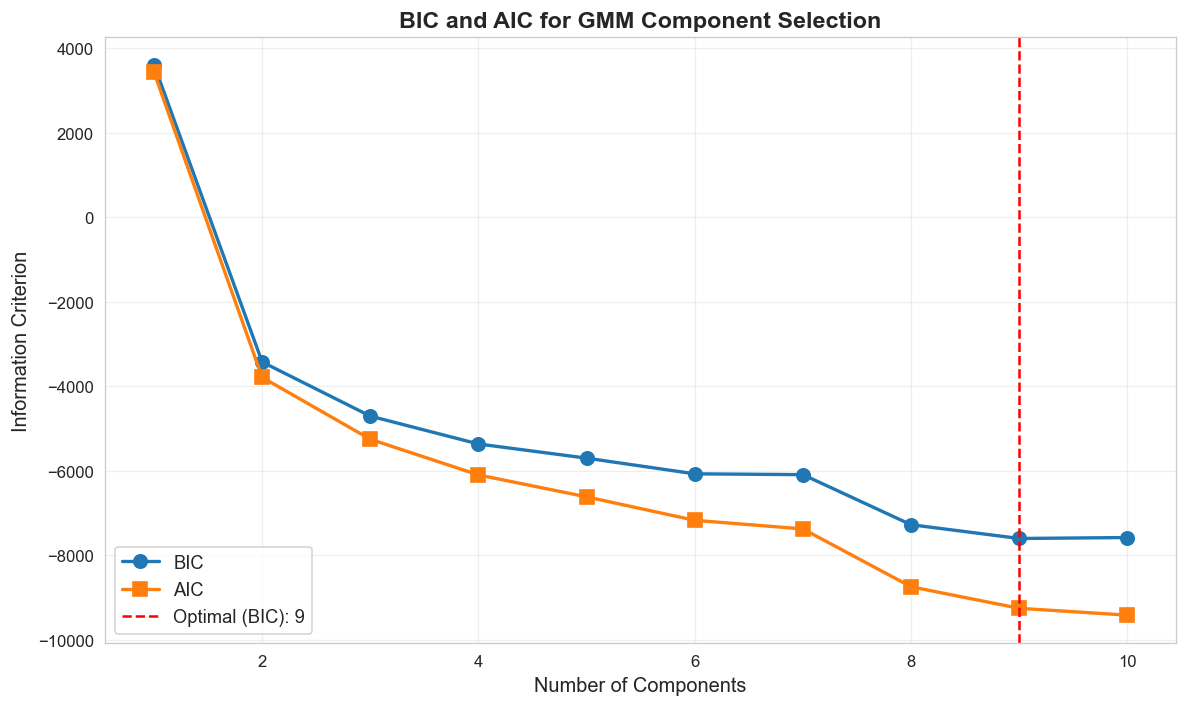

Saved: 01_bic_aic_selection.png


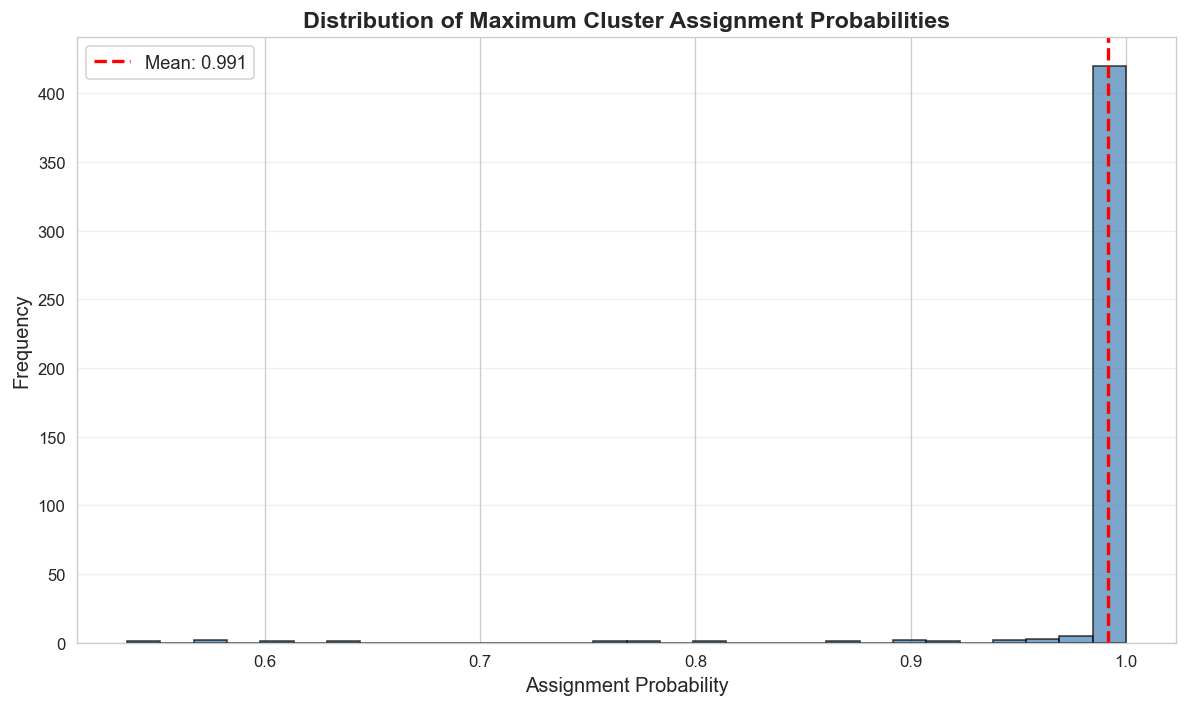

Saved: 02_assignment_probability.png


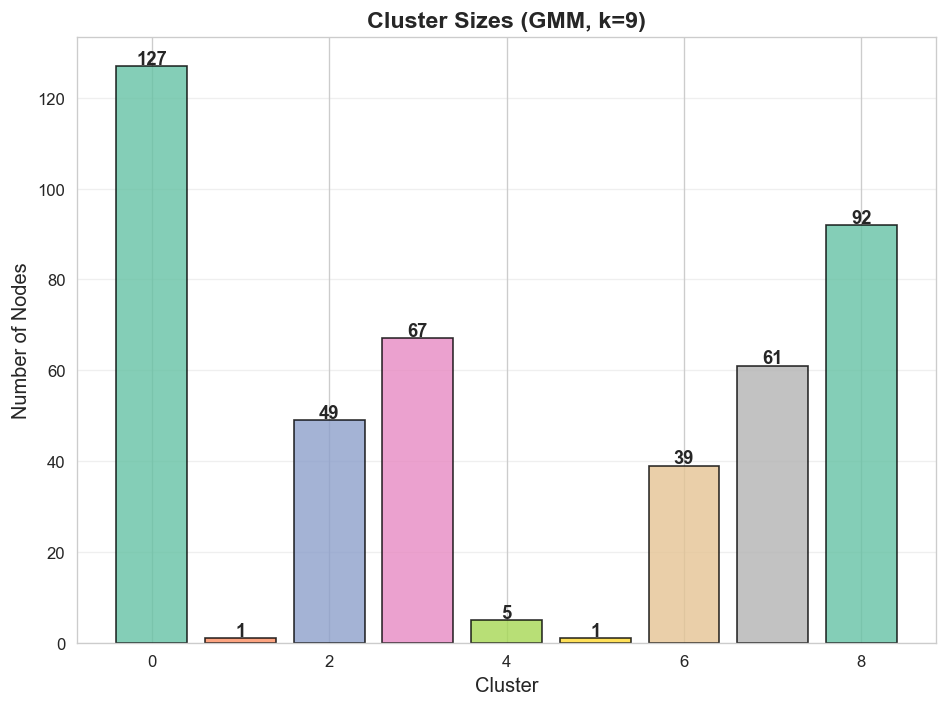

Saved: 03_cluster_sizes.png


In [10]:
## 6. Visualizations

# Create figures directory
os.makedirs('figures', exist_ok=True)

# 1. BIC/AIC comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(n_components_range, bic_scores, 'o-', label='BIC', linewidth=2, markersize=8)
ax.plot(n_components_range, aic_scores, 's-', label='AIC', linewidth=2, markersize=8)
ax.axvline(x=optimal_n_bic, color='red', linestyle='--', label=f'Optimal (BIC): {optimal_n_bic}')
ax.set_xlabel('Number of Components', fontsize=12)
ax.set_ylabel('Information Criterion', fontsize=12)
ax.set_title('BIC and AIC for GMM Component Selection', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/01_bic_aic_selection.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 01_bic_aic_selection.png')

# 2. Assignment Probability Distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.hist(max_prob, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=max_prob.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {max_prob.mean():.3f}')
ax.set_xlabel('Assignment Probability', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Maximum Cluster Assignment Probabilities', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/02_assignment_probability.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 02_assignment_probability.png')

# 3. Cluster sizes
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
colors = sns.color_palette('Set2', len(cluster_counts))
ax.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Number of Nodes', fontsize=12)
ax.set_title(f'Cluster Sizes (GMM, k={optimal_n_bic})', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cluster_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_cluster_sizes.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 03_cluster_sizes.png')

C:\Users\MyName\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Adjusted Rand Index (GMM vs K-means): 0.6035

GMM Silhouette Score: 0.3183
K-means Silhouette Score: 0.5004

GMM Davies-Bouldin Index: 0.9540
K-means Davies-Bouldin Index: 0.5677


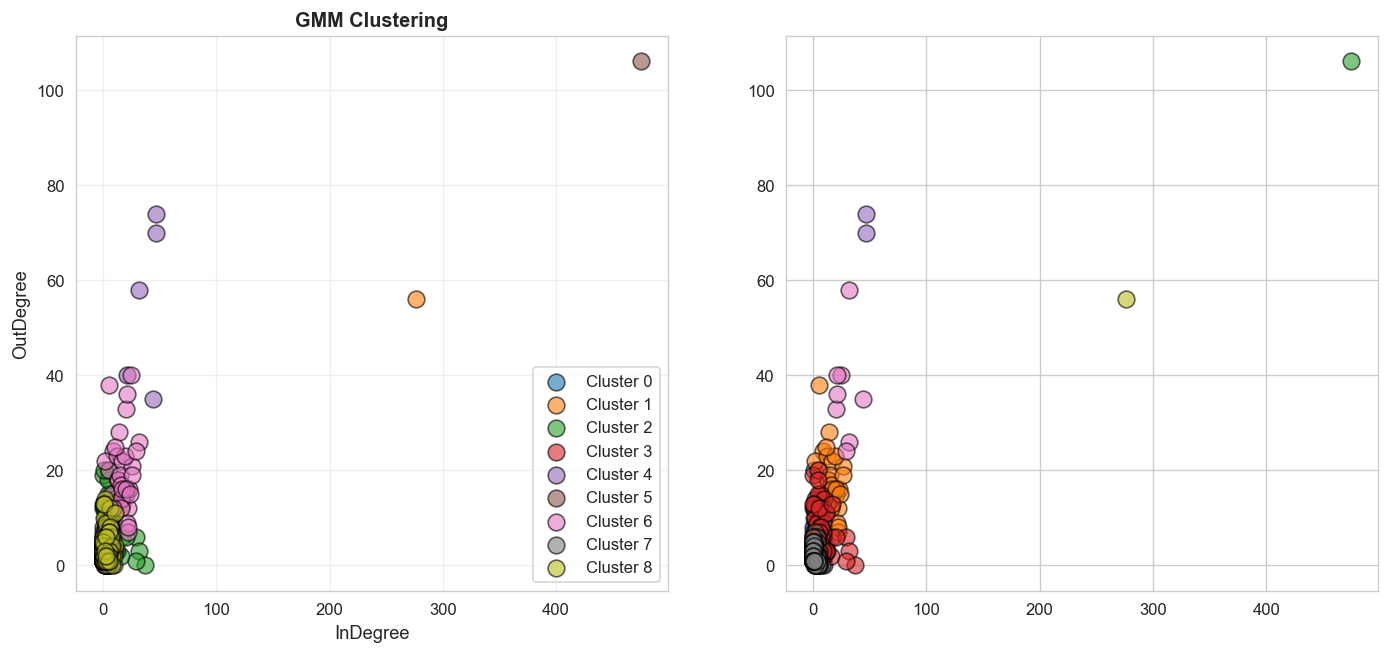

In [12]:
## 7. Comparison with K-means

# Fit K-means with same optimal number of clusters
kmeans = KMeans(n_clusters=optimal_n_bic, random_state=RSEED, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Compare assignments
ari = adjusted_rand_score(cluster_labels, kmeans_labels)
print(f'Adjusted Rand Index (GMM vs K-means): {ari:.4f}')

# Validation metrics
gmm_silhouette = silhouette_score(X_scaled, cluster_labels)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
gmm_db = davies_bouldin_score(X_scaled, cluster_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)

print(f'\nGMM Silhouette Score: {gmm_silhouette:.4f}')
print(f'K-means Silhouette Score: {kmeans_silhouette:.4f}')
print(f'\nGMM Davies-Bouldin Index: {gmm_db:.4f}')
print(f'K-means Davies-Bouldin Index: {kmeans_db:.4f}')

# Visualization comparison - use centralities_clean (442 rows) not original (445 rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# GMM cluster probabilities by assignment
ax = axes[0]
for cluster in range(optimal_n_bic):
    mask = cluster_labels == cluster
    ax.scatter(centralities_clean.iloc[mask, 1], centralities_clean.iloc[mask, 2], 
              label=f'Cluster {cluster}', s=100, alpha=0.6, edgecolor='black')
ax.set_xlabel(feature_cols[0], fontsize=11)
ax.set_ylabel(feature_cols[1], fontsize=11)
ax.set_title('GMM Clustering', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# K-means clusters
ax = axes[1]
for cluster in range(optimal_n_bic):
    mask = kmeans_labels == cluster
    ax.scatter(centralities_clean.iloc[mask, 1], centralities_clean.iloc[mask, 2], 
              label=f'Cluster {cluster}', s=100, alpha=0.6, edgecolor='black')

In [13]:
## 8. PDF Handout Generation

from reportlab.lib.pagesizes import letter, A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, PageBreak
from reportlab.lib import colors
from reportlab.lib.enums import TA_LEFT, TA_CENTER, TA_JUSTIFY

pdf_path = 'Ch09_ModelBasedClustering_Handout.pdf'
doc = SimpleDocTemplate(pdf_path, pagesize=letter,
                        rightMargin=0.75*inch, leftMargin=0.75*inch,
                        topMargin=0.75*inch, bottomMargin=0.75*inch)

styles = getSampleStyleSheet()
styleN = styles['Normal']
styleN.fontSize = 11
styleN.alignment = TA_JUSTIFY

story = []

# Title
title = Paragraph('<b>Chapter 9: Model-Based Clustering using Gaussian Mixture Models</b>', styles['Heading1'])
story.append(title)
story.append(Spacer(1, 12))

# Introduction
story.append(Paragraph('<b>1. Introduction</b>', styles['Heading2']))
intro = (
    'Gaussian Mixture Models (GMM) provide a probabilistic approach to clustering that assigns soft (probabilistic) '
    'labels to observations. Unlike K-means (which uses hard assignments), GMM quantifies uncertainty in cluster membership '
    'through cluster assignment probabilities. BIC and AIC information criteria help determine the optimal number of clusters.'
)
story.append(Paragraph(intro, styleN))
story.append(Spacer(1, 12))

# Dataset & Variables
story.append(Paragraph('<b>2. Dataset & Variables</b>', styles['Heading2']))
dataset = (
    f'Network centrality measures from a Moodle MOOC course (n={len(centralities)} nodes). '
    f'Features: {', '.join(feature_cols)}. '
    'Centrality measures capture each student\'s position and role in the course interaction network.'
)
story.append(Paragraph(dataset, styleN))
story.append(Spacer(1, 12))

# Methods
story.append(Paragraph('<b>3. Methods</b>', styles['Heading2']))
methods = (
    'Features were standardized (zero mean, unit variance). Gaussian Mixture Models were fit for k=1 to k=10 components. '
    'BIC (Bayesian Information Criterion) and AIC (Akaike Information Criterion) were computed for each k. '
    f'The optimal model (k={optimal_n_bic}) was selected based on minimum BIC. '
    'Soft cluster probabilities were extracted, and results compared with K-means clustering.'
)
story.append(Paragraph(methods, styleN))
story.append(Spacer(1, 12))

# Results
story.append(Paragraph('<b>4. Results</b>', styles['Heading2']))
story.append(Spacer(1, 6))

try:
    if os.path.exists('figures/01_bic_aic_selection.png'):
        story.append(Paragraph('<b>Model Selection (BIC/AIC):</b>', styleN))
        story.append(Image('figures/01_bic_aic_selection.png', width=500, height=300))
        story.append(Spacer(1, 6))
        story.append(Paragraph(
            f'Fig 1: BIC and AIC scores across different numbers of components. '
            f'BIC achieves minimum at k={optimal_n_bic}, indicating the optimal cluster count for this dataset.',
            styleN))
        story.append(Spacer(1, 12))
except Exception as e:
    print(f'Could not load BIC/AIC figure: {e}')

try:
    if os.path.exists('figures/02_assignment_probability.png'):
        story.append(Paragraph('<b>Assignment Probabilities:</b>', styleN))
        story.append(Image('figures/02_assignment_probability.png', width=500, height=300))
        story.append(Spacer(1, 6))
        story.append(Paragraph(
            f'Fig 2: Distribution of maximum cluster assignment probabilities. '
            f'Mean probability: {max_prob.mean():.3f}, indicating generally confident cluster assignments.',
            styleN))
        story.append(Spacer(1, 12))
except Exception as e:
    print(f'Could not load assignment probability figure: {e}')

try:
    if os.path.exists('figures/03_cluster_sizes.png'):
        story.append(Paragraph('<b>Cluster Distribution:</b>', styleN))
        story.append(Image('figures/03_cluster_sizes.png', width=450, height=300))
        story.append(Spacer(1, 6))
        story.append(Paragraph(
            f'Fig 3: Distribution of nodes across {optimal_n_bic} clusters. '
            'Cluster sizes reflect the diversity of student roles in the network.',
            styleN))
        story.append(Spacer(1, 12))
except Exception as e:
    print(f'Could not load cluster sizes figure: {e}')

try:
    if os.path.exists('figures/04_gmm_vs_kmeans.png'):
        story.append(Paragraph('<b>GMM vs K-means Comparison:</b>', styleN))
        story.append(Image('figures/04_gmm_vs_kmeans.png', width=520, height=240))
        story.append(Spacer(1, 6))
        story.append(Paragraph(
            f'Fig 4: Comparison of cluster assignments (left: GMM with soft probabilities, right: K-means with hard assignments). '
            f'Adjusted Rand Index: {ari:.3f}. GMM Silhouette: {gmm_silhouette:.3f}; K-means Silhouette: {kmeans_silhouette:.3f}.',
            styleN))
        story.append(Spacer(1, 12))
except Exception as e:
    print(f'Could not load comparison figure: {e}')

story.append(PageBreak())

# Interpretation
story.append(Paragraph('<b>5. Interpretation</b>', styles['Heading2']))
interp = (
    'The Gaussian Mixture Model identifies distinct student subgroups based on network centrality patterns. '
    'Soft probabilities quantify the uncertainty in cluster assignments—students with high probabilities are prototypical '
    'cluster members, while those with moderate probabilities occupy boundary regions. '
    f'The {optimal_n_bic}-cluster solution balances model complexity (penalized by BIC) with data fit quality.'
)
story.append(Paragraph(interp, styleN))
story.append(Spacer(1, 12))

# Limitations
story.append(Paragraph('<b>6. Limitations</b>', styles['Heading2']))
lim = (
    'GMM assumes multivariate normal distributions within clusters, which may not hold for all datasets. '
    'BIC/AIC comparison assumes the models are nested or comparable. '
    'Interpretation of cluster probabilities depends on adequate model convergence and initialization.'
)
story.append(Paragraph(lim, styleN))
story.append(Spacer(1, 12))

# Reproducibility
story.append(Paragraph('<b>7. Reproducibility</b>', styles['Heading2']))
repro = (
    'To reproduce: run the notebook in order from setup through PDF generation. '
    'All intermediate figures are saved under `figures/` and clustering results under `gmm_clustering_results.csv`.'
)
story.append(Paragraph(repro, styleN))
story.append(Spacer(1, 12))

# Timestamp
story.append(Paragraph(f'Generated on: {dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}', styleN))

# Build PDF
try:
    doc.build(story)
    print(f'Saved PDF handout to {pdf_path}')
except Exception as e:
    print(f'PDF generation failed: {e}')

Saved PDF handout to Ch09_ModelBasedClustering_Handout.pdf
